## Global Disaster and Economic Impact Explorer (2020 - 2025)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

### Importing Data

In order to successfully run this notebook, we need the two datasets:

- Dataset 1: [Global Climate Events and Economic Impact Dataset](https://www.kaggle.com/datasets/uom190346a/global-climate-events-and-economic-impact-dataset/data)

- Dataset 2: [Global Economic Indicators (2010–2025) - World Bank](https://www.kaggle.com/datasets/tanishksharma9905/global-economic-indicators-20102025)

Download these into the `datasets` folder of this repo.

In [2]:
disaster_df = pd.read_csv('datasets/global_climate_events_economic_impact_2020_2025.csv')
indicators_df_full = pd.read_csv('datasets/world_bank_data_2025.csv')

### Data Filtering

To ensure consistency between the disaster and economic indicator datasets, we performed country name standardization and filtering.

First we identified countries present in the disaster dataset but missing from the indicators dataset. From these discrepancies, we created a mapping dictionary to align country names between the two datasets. This mapping was then applied to the disaster dataset.

After harmonizing country names, we filtered the economic dataset to retain only countries that appear in the disaster dataset.

These steps ensures that subsequent analyses and visualizations are based on consistent and matching country records across both datasets.

In [3]:
# sets of countries
disaster_countries = set(disaster_df['country'].unique())
indicator_countries = set(indicators_df_full['country_name'].unique())

# countries in disaster_df not in indicators_df
print(disaster_countries - indicator_countries)

{'UAE', 'Egypt', 'Vietnam', 'Turkey', 'Russia', 'South Korea', 'Czech Republic'}


In [4]:
# mapping of country names in disaster_df to names in indicators_df
country_name_map = {
    'Czech Republic': 'Czechia',
    'Egypt': 'Egypt, Arab Rep.',
    'Russia': 'Russian Federation',
    'South Korea': 'Korea, Rep.',
    'Turkey': 'Turkiye',
    'UAE': 'United Arab Emirates',
    'Vietnam': 'Viet Nam'
}

# apply mapping to disaster_df
disaster_df['country'] = disaster_df['country'].replace(country_name_map)

# filter indicators_df to include only countries in disaster_df
indicators_df = indicators_df_full[indicators_df_full['country_name'].isin(disaster_df['country'].unique())]

### Data Cleaning and Preprocessing

Before analysis, both datasets were cleaned and standardized to ensure consistency and usability.

For the disaster dataset, we removed irrelevant columns such as event_id, converted date strings into proper datetime objects, and prepared categorical variables for later encoding.

For the Economic Indicators dataset, we dropped unnecessary columns like country identifiers and standardized monetary values (e.g., GDP and Gross National Income) to millions of USD for easier comparison and visualization. Column names were then updated to reflect these new units.

These cleaning and preprocessing steps ensure that both datasets are in a consistent format, making them suitable for accurate merging, analysis, and visualization in subsequent stages.

In [5]:
# ---- Disaster Dataset Cleaning ---- #

# drop useless columns in disaster dataframe
disaster_df = disaster_df.drop(columns=['event_id'])

# datetime conversion
disaster_df['date'] = pd.to_datetime(disaster_df['date'])

# encoding


# ---- Indicators Dataset Cleaning ---- #

# drop useless columns in indicators dataframe
indicators_df = indicators_df.drop(columns=['country_id'])

# standarize monetary columns to million USD
indicators_df.loc[:, 'GDP (Current USD)'] = indicators_df['GDP (Current USD)'] / 1e6
#indicators_df.loc[:, 'GDP per Capita (Current USD)'] = indicators_df['GDP per Capita (Current USD)'] / 1e6
indicators_df.loc[:, 'Gross National Income (USD)'] = indicators_df['Gross National Income (USD)'] / 1e6

# rename standarized columns
indicators_df.rename(columns={
    'GDP (Current USD)': 'GDP (Million USD)',
    #'GDP per Capita (Current USD)': 'GDP per Capita (Million USD)',
    'Gross National Income (USD)': 'Gross National Income (Million USD)'
}, inplace=True)

# encoding

#### Missingness

From the inital dataset inspection, we observed that the diasters dataset was complete, but the indicators dataset had missing values. To assess data missingess, we conducted an analysis on the economic indicators dataset.

We began by visualizing overall missing values using a heatmap, which highlights the presence or absence of data across all variables and years. 

To explore missingness patterns more interactively, we created a dynamic country level heatmap allowing users to select a country and examine which indicators have missing values over time.

Next, we analyzed whether missingness in certain indicators was related to the actual values of others. By generating missingness indicator variables (binary flags showing where data is missing) and computing their correlations with the original numeric variables, we visualized potential dependencies using a correlation heatmap.

This analysis helps identify systematic patterns of missing data, such as missingness concentrated in specific indicators, years, or economic conditions, informing our data imputation or exclusion decisions in later stages.

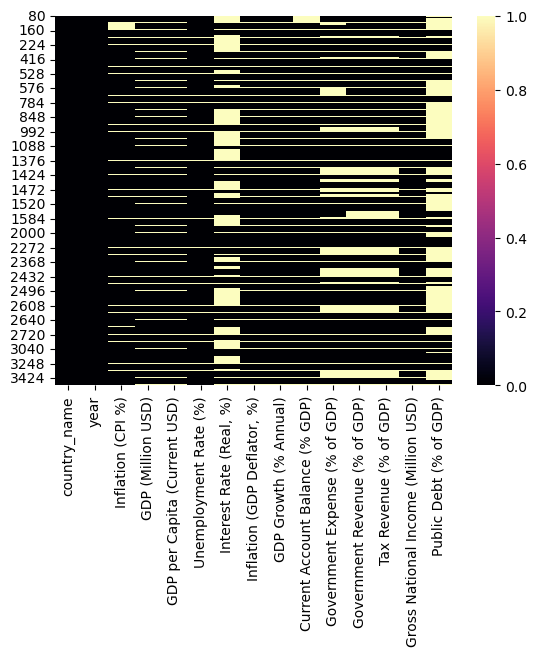

In [ ]:
sns.heatmap(indicators_df.isna(), cmap="magma")

#plt.savefig('images/missing_values_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:
countries = indicators_df['country_name'].unique()
indicator_cols = [c for c in indicators_df.columns if c not in ['country_name', 'country_id', 'year']]

# Get the full year range (to keep axis consistent)
years = sorted(indicators_df['year'].unique())

# Build initial figure
country = countries[0]
subset = indicators_df[indicators_df['country_name'] == country]
mask = subset[indicator_cols].isna().astype(int)
mask['year'] = subset['year']
pivot = mask.melt(id_vars='year', var_name='Indicator', value_name='Missing') \
             .pivot(index='Indicator', columns='year', values='Missing') \
             .reindex(index=indicator_cols, columns=years, fill_value=0)

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns,
    y=pivot.index,
    colorscale=[[0, 'white'], [1, 'red']],
    showscale=False
))

# Add dropdown buttons
buttons = []
for c in countries:
    subset = indicators_df[indicators_df['country_name'] == c]
    mask = subset[indicator_cols].isna().astype(int)
    mask['year'] = subset['year']
    pivot = mask.melt(id_vars='year', var_name='Indicator', value_name='Missing') \
                 .pivot(index='Indicator', columns='year', values='Missing') \
                 .reindex(index=indicator_cols, columns=years, fill_value=0)
    
    buttons.append(dict(
        label=c,
        method="update",
        args=[{"z": [pivot.values]}, {"title": f"Missingness Heatmap for {c}"}]
    ))

fig.update_layout(
    title=f"Missingness Heatmap for {country}",
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "x": 1.15,
        "y": 1,
        "showactive": True
    }],
    xaxis_title="Year",
    yaxis_title="Indicator",
    yaxis=dict(autorange="reversed"),
    width=900,
    height=800
)
fig.show()

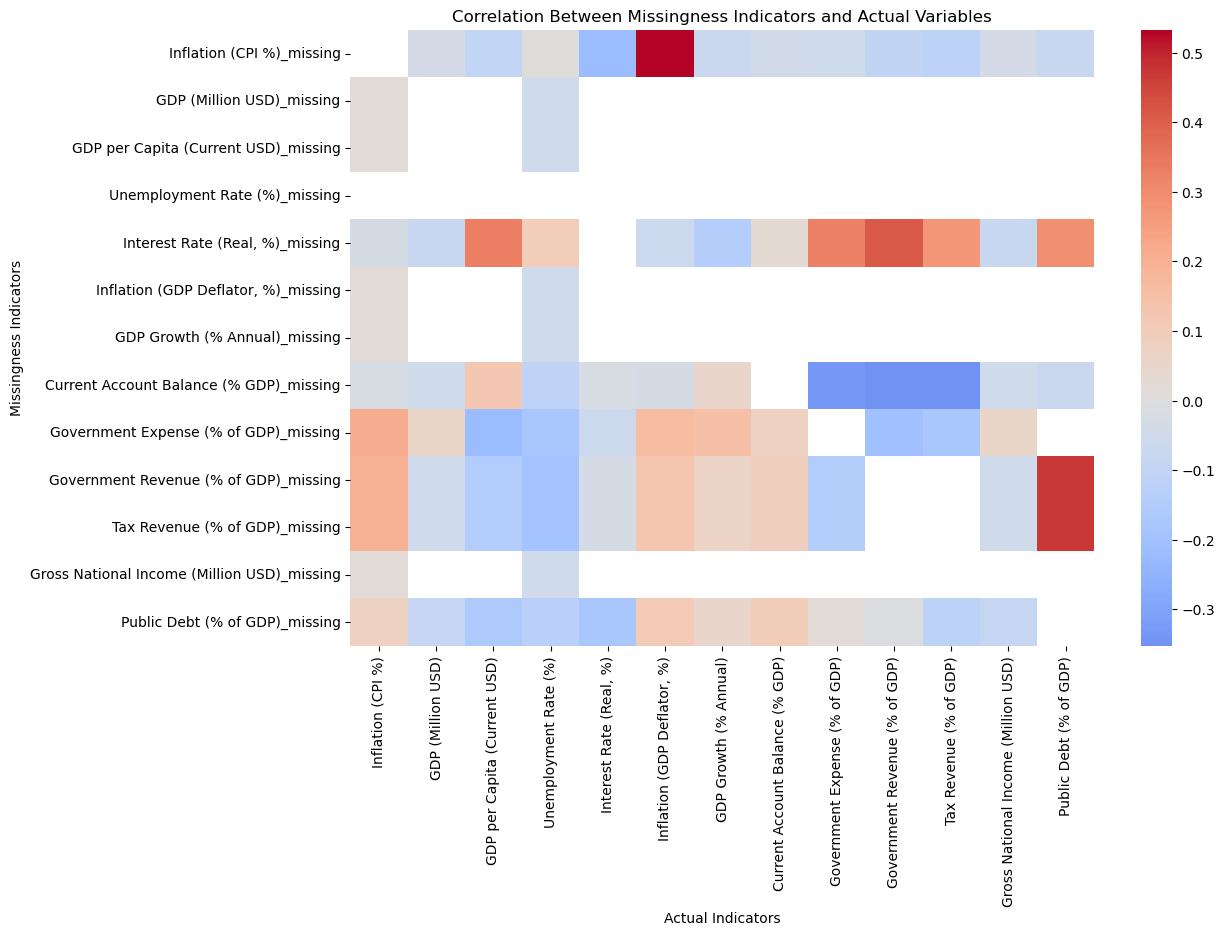

In [ ]:
# numeric columns only (exclude country/year identifiers)
indicator_cols = [c for c in indicators_df.columns if c not in ['country_name', 'year']]

# Create missingness indicator DataFrame
missing_indicators = indicators_df[indicator_cols].isna().astype(int)
missing_indicators.columns = [f"{c}_missing" for c in indicator_cols]

# Concatenate numeric data and missingness indicators
combined = pd.concat([indicators_df[indicator_cols], missing_indicators], axis=1)

# Compute correlation
corr = combined.corr()

# Extract block: rows = missingness indicators, columns = actual variables
corr_block = corr.loc[missing_indicators.columns, indicator_cols]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Between Missingness Indicators and Actual Variables")
plt.xlabel("Actual Indicators")
plt.ylabel("Missingness Indicators")
#plt.savefig('images/missingness_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

**Missingness Insights and Interpretation**

From our missingness visualizations, several key patterns emerged that provide insight into the structure and potential mechanisms driving the missing data.

1. Temporal and Variable-Level Patterns

The indicies vs indicators heatmap and interactive country level heatmaps revealed horizontal bands, where certain countries exhibited missing values across multiple economic indicators—particularly for the years 2024 and 2025. This pattern suggests that for some nations, data collection or reporting may not yet have been completed for the most recent years, which is common for international economic datasets that lag in publication. Conversely, vertical bands indicated that specific indicators were missing across many countries and years.

2. Correlation Between Missingness and Observed Values

To further probe the nature of missingness, we examined the correlation between each numeric indicator and its corresponding missingness flag (a binary variable indicating whether a value was missing).

By computing correlations between all indicators and their missingness indicators, we generated a correlation heatmap to detect dependencies.

If a missingness flag for one variable was highly correlated with another indicator, it would suggest informative missingness, where missing values depend on certain economic conditions.

The correlation heatmap between indicator values and their corresponding missingness flags revealed several moderate correlations, suggesting that missingness is associated with observed economic conditions rather than occurring randomly. 

3. Missingness Mechanism

Together, these patterns suggest that the missing data mechanism likely follows a Missing At Random (MAR) structure.
Under MAR, the probability of a value being missing is related to observed data, but not to the missing value itself. Under MAR, missing data can be reasonably modeled and imputed using observed variables, as missingness depends on known factors such as reporting completeness or economic development rather than the unobserved values themselves.

This is an important finding as it implies that statistical imputation methods that rely on observed data can be reasonably applied without introducing significant bias.

#### Imputation

After identifying that missing values followed a Missing At Random (MAR) pattern, we applied a two-stage imputation process to estimate the missing economic indicators while preserving the statistical properties of the data.

1. Stochastic Regression Imputation

In the first step, we used stochastic regression imputation to model each indicator as a function of time (year) within each country.

A simple linear regression was fit to the observed data points for each country-indicator pair. Missing values were then predicted based on the regression trend, with an additional random noise component added to reflect natural variability.

This approach captures temporal trends—such as GDP growth or inflation patterns, while preserving realistic variation in the imputed data rather than producing overly smooth or deterministic estimates.

If a country-indicator pair lacked enough data points (fewer than two), those values were skipped and deferred to the next imputation stage.

2. K-Nearest Neighbors (KNN) Imputation

In the second step, we applied KNN imputation to handle remaining missing values. This method imputes missing entries based on the similarity between countries within the same year, using other available indicators as features.
By considering neighboring countries with similar economic profiles, this step helps fill gaps that cannot be explained by temporal trends alone (e.g., missing data for a specific country-year where no regression fit was possible).

By combining stochastic regression (temporal structure) and KNN (cross-sectional relationships), the imputation process leverages both within-country temporal dynamics and between-country economic similarities.
This hybrid approach ensures that imputed values are not only statistically consistent with each country’s historical trend but also aligned with global economic patterns observed in the dataset.

In [10]:
def stochastic_regression_imputation(df, indicator_cols):
    df_imputed = df.copy()

    for country in df['country_name'].unique():
        subset = df[df['country_name'] == country].sort_values('year')

        for col in indicator_cols:
            y = subset[col]
            x = subset['year'].values.reshape(-1, 1)

            # Case 1: Not enough data points to fit regression
            if y.notna().sum() < 2:
                continue  # Leave for KNN step later

            # Fit regression over time
            model = LinearRegression().fit(x[y.notna()], y[y.notna()])
            preds = model.predict(x)

            # Estimate residual variance and add stochastic noise
            residual_std = np.std(y[y.notna()] - model.predict(x[y.notna()]))
            stochastic_preds = preds + np.random.normal(0, residual_std, size=len(preds))

            # Fill missing only
            filled = y.copy()
            filled[y.isna()] = stochastic_preds[y.isna()]
            df_imputed.loc[subset.index, col] = filled

    return df_imputed


def knn_imputation(df, indicator_cols, n_neighbors=5):
    df_knn = df.copy()
    imputer = KNNImputer(n_neighbors=n_neighbors)

    # Apply KNN imputation separately for each year
    for year in df_knn['year'].unique():
        year_mask = df_knn['year'] == year
        df_year = df_knn.loc[year_mask, indicator_cols]

        # Skip if all NaN (nothing to impute)
        #if df_year.isna().all().all():
            #continue

        df_knn.loc[year_mask, indicator_cols] = imputer.fit_transform(df_year)

    return df_knn

In [11]:
# ---- Run the combined imputation ----
indicator_cols = [col for col in indicators_df.columns if col not in ['country_name', 'year']]

# Step 1: Stochastic regression
indicators_df_imputed_step1 = stochastic_regression_imputation(indicators_df, indicator_cols)

# Step 2: KNN imputation
indicators_df_imputed = knn_imputation(indicators_df_imputed_step1, indicator_cols)

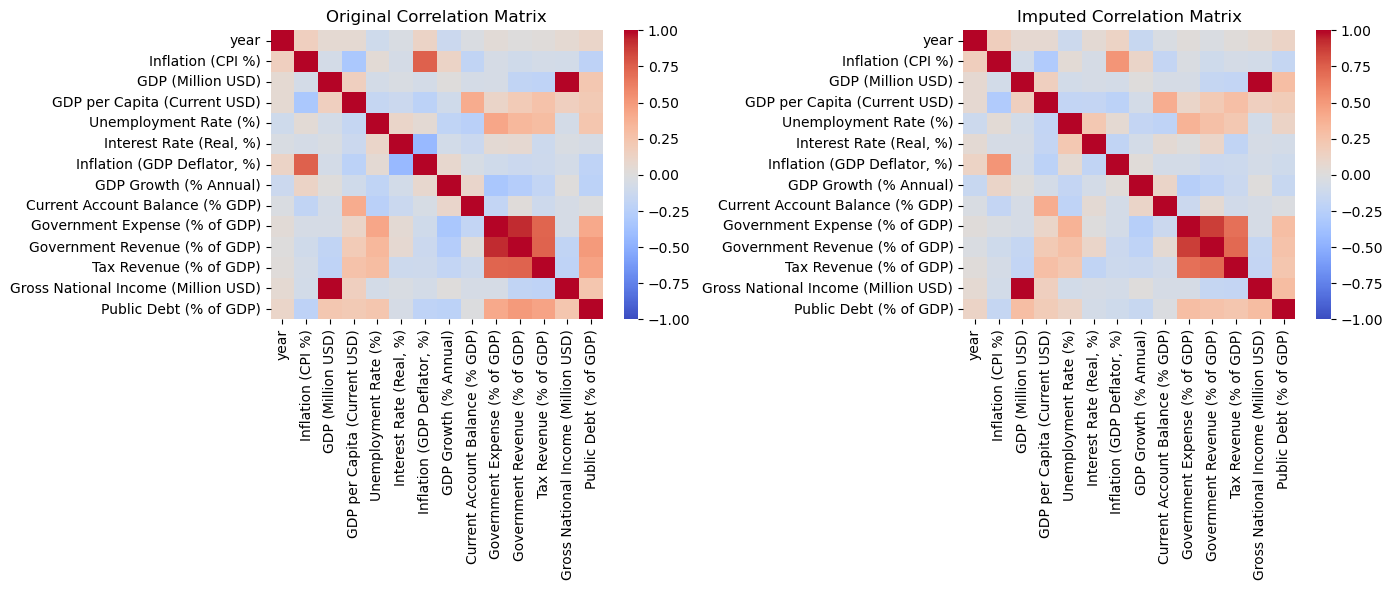

In [ ]:
# ---- Imputation Analysis ----

numeric_cols = indicators_df.select_dtypes(include=['number']).columns

corr_orig = indicators_df[numeric_cols].corr()
corr_imputed = indicators_df_imputed[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_orig, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[0].set_title('Original Correlation Matrix')

sns.heatmap(corr_imputed, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[1].set_title('Imputed Correlation Matrix')

plt.tight_layout()
#plt.savefig('images/correlation_structure_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Post-Imputation Evaluation**

To assess the impact of our imputation process, we compared the correlation structure of the dataset before and after imputation. Specifically, we generated correlation heatmaps of all economic indicators for both the original dataset and the imputed dataset.

The goal of this comparison was to determine whether the imputation introduced systematic bias or altered the underlying relationships among indicators. Ideally, an effective imputation method should restore missing values without distorting the multivariate structure of the data.

Upon inspection, the two heatmaps displayed highly similar correlation patterns, indicating that the overall structure of relationships between economic indicators was well preserved. While minor variations were expected due to the stochastic component and interpolation effects, no significant deviations were observed.

This consistency suggests that the hybrid imputation strategy (stochastic regression + KNN) successfully reconstructed missing values while maintaining the original data’s statistical integrity and avoiding artificial correlations or structural bias.

In [12]:
# ---- final cleaning steps ----

# filter indicators dataset for only years 2020-2025 to match disasters dataset
indicators_df_imputed = indicators_df_imputed[indicators_df_imputed['year'] >= 2020]

# saving cleaned datasets
#disaster_df.to_csv('datasets/disaster_df.csv', index=False)
#indicators_df_imputed.to_csv('datasets/indicators_df_imputed.csv', index=False)

### Exploratory Data Analysis (EDA)

In [13]:
# Group and aggregate totals per year + event_type
disaster_counts = (
    disaster_df.groupby(['year', 'event_type'])
    .agg(
        count=('event_type', 'size'),
        affected_population=('affected_population', 'sum'),
        total_casualties=('total_casualties', 'sum')
    )
    .reset_index()
)

years = sorted(disaster_counts['year'].unique())
data = []

# Create a bar trace for each year
for y in years:
    subset = disaster_counts[disaster_counts['year'] == y]
    
    hover_text = [
        f"Count: {count:,} <br>"
        f"Affected Population: {affected_pop:,} <br>"
        f"Total Casualties: {casualties:,} <br>"
        for count, affected_pop, casualties in zip(
            subset['count'],
            subset['affected_population'],
            subset['total_casualties']
        )
    ]
            
    data.append(
        go.Bar(
            x=subset['event_type'],
            y=subset['count'],
            name=str(y),
            marker_color='steelblue',  # uniform color
            visible=(y == years[0]),    # only first year visible initially
            hovertext=hover_text,
            hoverinfo='text'
        )
    )

# Create dropdown buttons (one per year)
dropdown_buttons = [
    {
        'label': str(y),
        'method': 'update',
        'args': [
            {'visible': [year == y for year in years]},
            {'title': f'Disaster Type Counts - {y}'}
        ]
    }
    for y in years
]

# Build the figure layout
fig = go.Figure(data=data)
fig.update_layout(
    updatemenus=[{
        'buttons': dropdown_buttons,
        'direction': 'down',
        'showactive': True,
        'x': 0.1,
        'xanchor': 'left',
        'y': 1.15,
        'yanchor': 'top'
    }],
    title=f'Disaster Type Counts - {years[0]}',
    xaxis_title='Disaster Type',
    yaxis_title='Count',
    showlegend=False
)

fig.show()


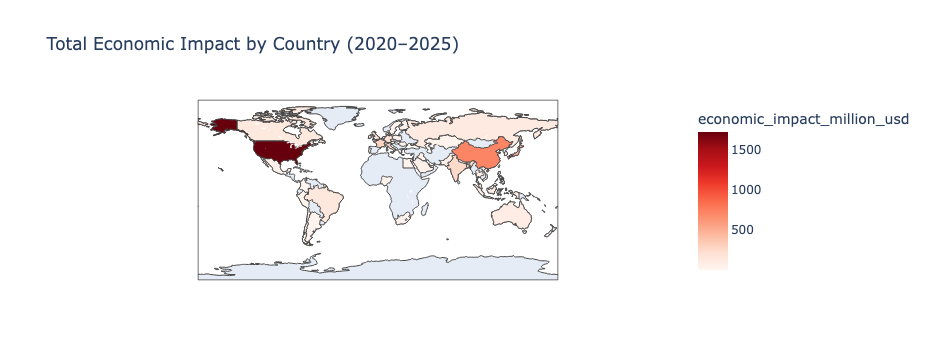

In [14]:
country_summary = (
    disaster_df.groupby('country', as_index=False)
    .agg({'economic_impact_million_usd': 'sum'})
)

fig = px.choropleth(
    country_summary,
    locations='country',
    locationmode='country names',
    color='economic_impact_million_usd',
    title='Total Economic Impact by Country (2020–2025)',
    color_continuous_scale='Reds'
)

fig.update_traces(
    hovertemplate=(
        '<br>%{location}</b><br>' + 
        'Total Economic Impact: $%{z:.0f} million<br>' +
        '<extra></extra>'
    )
)

fig.show()

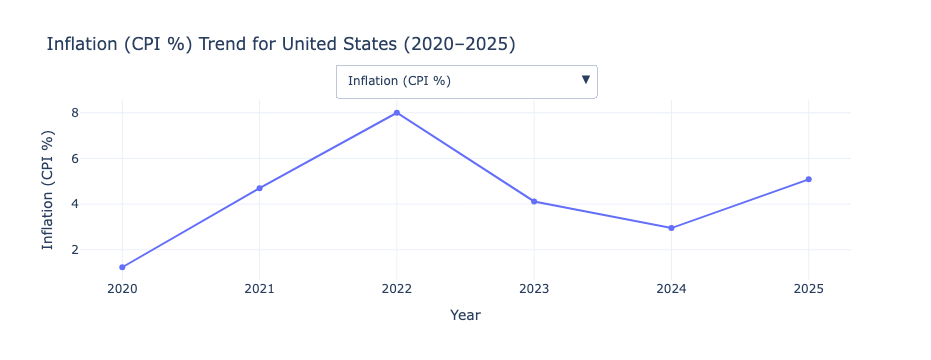

In [15]:
# Choose any country dynamically (you can loop through, or later make it a dropdown)
selected_country = 'United States'

# Filter for selected country
country_data = indicators_df_imputed[indicators_df_imputed['country_name'] == selected_country]

# Identify indicator columns
indicators = [col for col in indicators_df_imputed.columns if col not in ['country_name', 'year']]

# Create the base figure
fig = go.Figure()

# Add a line for each indicator (invisible except first)
for ind in indicators:
    fig.add_trace(
        go.Scatter(
            x=country_data['year'],
            y=country_data[ind],
            mode='lines+markers',
            name=ind,
            visible=(ind == indicators[0]),
            hovertemplate=f"{ind}: %{{y:.2f}}<extra></extra>"
        )
    )

# Dropdown buttons (auto title updates)
buttons = []
for indicator_name in indicators:
    visible_flags = [indicator_name == i for i in indicators]
    buttons.append(
        dict(
            method="update",
            label=indicator_name,
            args=[
                {"visible": visible_flags},
                {"title": f"{indicator_name} Trend for {selected_country} (2020–2025)",
                 "yaxis": {"title": indicator_name}}
            ],
        )
    )

# Layout (dynamic title)
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.5,
            xanchor="center",
            y=1.2,
            yanchor="top",
        )
    ],
    title=f"{indicators[0]} Trend for {selected_country} (2020–2025)",
    xaxis_title="Year",
    yaxis_title=indicators[0],
    template="plotly_white"
)

fig.show()
